# UCSB Data Science Capstone, Blue Alpha Group #3, Interim Report

# Introduction

Companies today invest heavily in a wide range of marketing channels, including digital platforms such as Meta, Google, and TikTok, as well as traditional channels like television. A fundamental challenge is determining how much each channel contributes to overall revenue. This is difficult because customer journeys are complex: individuals are often exposed to multiple channels before converting, external factors such as seasonality affect demand, and channels may interact with one another in ways that amplify or reduce their effectiveness.

Marketing Mix Modeling (MMM) is a statistical framework used to estimate the contribution of different marketing channels to business outcomes. By decomposing performance into channel level effects, MMM helps firms evaluate return on investment (ROI) and optimize budget allocation. However, a key limitation of many MMM approaches is the assumption that channels operate independently (Charan, n.d.). In practice, this assumption is often violated.

This project is conducted in collaboration with BlueAlpha, which focuses on applying data driven methods to improve marketing performance. In real world applications, BlueAlpha has observed that interactions between channels, such as one channel increasing the effectiveness of another or competing for the same audience, are common and can meaningfully impact performance measurement.

These interaction effects generally take two forms: synergy, where one channel enhances the effectiveness of another (a TV campaign driving increased search activity), and cannibalization, where channels compete for the same conversions in multichannel environments (Kollmann et al., 2012).

Failing to account for these effects can lead to biased estimates of channel effectiveness and suboptimal marketing decisions. Despite their importance, these interactions are not well captured in standard MMM frameworks. To address these complexities, modern approaches utilize Bayesian causal inference, such as the Google Meridian framework, to incorporate prior knowledge and quantify uncertainty in ROI estimates (Google Developers, 2024).

The objective of this project is to develop analytical tools that identify and quantify interactions between marketing channels prior to integration into a full MMM model. Specifically, we aim to detect statistically significant relationships between channels, assess whether these relationships indicate synergy or cannibalization, and measure the strength and timing of these effects. 

In the current phase of the project, we have implemented an expanded set of methods, including correlation analysis, residual diagnostics, statistical testing, time-lagged analysis, and Granger causality tests. These tools allow us to systematically identify potential channel interactions and rank them by strength and significance.

The remainder of this report is organized as follows. Section 2 describes the data and methodology. Section 3 presents the results of the interaction analysis. Section 4 outlines planned extensions for integrating interaction effects into a full MMM framework. Section 5 concludes with key findings and implications for marketing strategy.

# Problem of Interest

A central problem in this project is identifying whether marketing channels interact with one another in ways that violate the independence assumption commonly used in Marketing Mix Modeling (MMM). In particular, we aim to determine whether pairs of channels exhibit statistically significant relationships that indicate synergy, where channels reinforce each other, or cannibalization, where they compete for the same conversions.

Beyond simply detecting interactions, we seek to quantify their strength and statistical significance. This involves distinguishing meaningful relationships from noise by evaluating effect sizes, testing for significance, and ranking channel pairs based on the consistency and magnitude of their interactions. Accurately measuring these relationships is essential for understanding which interactions are actionable versus incidental.

Another key problem is capturing the temporal dynamics of channel interactions. Marketing effects often occur with delays, meaning that activity in one channel may influence another channel’s performance over time rather than immediately. We therefore aim to identify whether past values of one channel predict future outcomes in another, as well as determine the relevant time lags at which these relationships are strongest.

Finally, this project seeks to structure interaction insights in a way that supports integration into a full MMM framework. This includes identifying the most important channel relationships and generating evidence that can inform the inclusion of interaction terms in future models, ultimately improving the accuracy of ROI estimation and marketing decision-making.

# Materials and Methods


## Dataset

As our work is still in the production stage, we're using an anonymized dataset. The dataset simulates a weekly marketing campaign, where channel-level metrics such as spend and impressions serve as predictors, and total subscriptions act as the response variable. Below is a sample output:

In [1]:
import pandas as pd
pd.read_csv("../data/monthly_mocha.csv").head()

,date,subscriptions,meta_spend,meta_impressions,google_spend,google_impressions,snapchat_spend,snapchat_impressions,tiktok_spend,tiktok_impressions,moloco_spend,moloco_impressions,liveintent_spend,liveintent_impressions,roku_spend,roku_impressions,beehiiv_spend,beehiiv_impressions,amazon_spend,amazon_impressions
0,8/4/25,15540,91538.06648,16572258,116667.9945,6473132,94750.04035,3420454,0.0,0,6564.524233,367206,37766.44904,371854,0,0,18190.10332,181901,0.0,0
1,7/28/25,14525,93840.18612,25300600,180486.9558,9487127,99447.23218,3235285,0.0,0,18111.083980,820589,38543.27888,347850,0,0,20063.91811,200639,0.0,0
2,7/21/25,16880,48403.06780,14099214,200817.3250,7909118,84738.57435,4766750,0.0,0,9714.794608,369806,39697.42202,322865,0,0,20828.00074,208280,0.0,0
3,7/14/25,20113,49470.96783,13652072,215770.9242,7789279,83204.40500,4022680,0.0,0,16831.841440,554980,40561.34006,570418,0,0,24097.34426,240973,0.0,0
4,7/7/25,16492,48948.28744,10121002,209231.9668,6806878,82642.37271,4532105,0.0,0,17624.908800,894891,40012.42040,483619,0,0,19967.60420,199676,0.0,0


While the dataset contains a clear predictor-response pairing of channels to subscriptions, it also provides additional granularity within each channel, namely spend and impressions. This allows for analyses such as correlation studies to inform the inclusion of interaction terms, particularly in understanding how predictors influence one another. Since interaction terms can quickly complicate both model formulation and interpretation, examining these underlying relationships helps mitigate unnecessary complexity.

## Computational Techniques

The methods employed thus far focus on correlation analysis and regression modeling to identify significant channel relationships, detailed below.

### Heatmaps

**What it evaluates**

Heatmaps visualize the strength and direction of pairwise linear relationships between variables, allowing us to quickly identify highly correlated predictors and potential interaction candidates.

**Mathematical definition**

The values in the heatmap are defined as Pearson correlation coefficients:

$
\rho_{X,Y} = \frac{\text{Cov}(X,Y)}{\sigma_X \sigma_Y}
$

**Interpretation**

- $\rho \approx 1$: strong positive linear relationship  
- $\rho \approx -1$: strong negative linear relationship  
- $\rho \approx 0$: little to no linear relationship  

Clusters of high correlation suggest potential multicollinearity or meaningful interaction structures.

**Why it matters**

Heatmaps provide an initial visual screening tool to identify redundant predictors, detect candidate interaction terms, and guide more formal statistical testing.

### Granger Causality Tests with Benjamini–Hochberg Correction

**What the test evaluates**

Granger causality evaluates whether past values of one time series provide statistically significant information for predicting another time series, beyond what is contained in the past values of the target series itself. It reflects predictive usefulness rather than true causation and helps determine whether interaction terms are meaningful for inclusion.

**Model setup**

Consider two time series, $X_t$ and $Y_t$.

Restricted model:
$
Y_t = \alpha_0 + \sum_{i=1}^{p} \alpha_i Y_{t-i} + \epsilon_t
$

Unrestricted model:
$
Y_t = \beta_0 + \sum_{i=1}^{p} \beta_i Y_{t-i} + \sum_{i=1}^{p} \gamma_i X_{t-i} + u_t
$

That is, does the model using both the past values of $X$ *and* $Y$ have more predictive accuracy than the model that uses $Y$ alone?

**Null hypothesis**

$
H_0: \gamma_1 = \gamma_2 = \cdots = \gamma_p = 0
$

**Test statistic**

$
F = \frac{(RSS_r - RSS_u)/p}{RSS_u/(T - 2p - 1)}
$

where:
- $RSS_r$: residual sum of squares from the restricted model  
- $RSS_u$: residual sum of squares from the unrestricted model  
- $p$: number of lags  
- $T$: number of observations  

**Decision rule**

Reject $H_0$ if the F-statistic is sufficiently large or the p-value is small.

**Multiple testing problem**

Testing many variable pairs inflates the Type I error rate, increasing false positives. To mitigate this issue, we employ the Benjamini–Hochberg correction.

**Benjamini–Hochberg correction**

The Benjamini–Hochberg procedure controls the false discovery rate (also known as the false positive rate).

Given $m$ tests with p-values:
$
p_1, p_2, \dots, p_m
$

Sort:
$
p_{(1)} \leq p_{(2)} \leq \cdots \leq p_{(m)}
$

Choose $\alpha$ and find the largest $k$ such that:
$
p_{(k)} \leq \frac{k}{m} \alpha
$

Reject:
$
p_{(1)}, \dots, p_{(k)}
$

This ensures:
$
\mathbb{E}\left[\frac{\text{False Positives}}{\text{Total Rejections}}\right] \leq \alpha
$

### Partial R-Squared

**What it evaluates**

Partial $R^2$ measures the additional explanatory power of a variable after accounting for other predictors in the model. In this case, we utilize it to quantify the effectiveness of our interaction terms within a multiple linear regression framework.

**Multiple linear regression context**

We model the response as a linear combination of predictors:

$
Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \cdots + \beta_k X_k + \epsilon
$

where each coefficient $\beta_j$ represents the marginal effect of predictor $X_j$ on the response, holding all other variables constant.

**Mathematical definition**

Let $RSS_r$ be from the restricted model and $RSS_u$ from the unrestricted model:

$
R^2_{\text{partial}} = \frac{RSS_r - RSS_u}{RSS_r}
$

where:
- $RSS_r$: residual sum of squares from the restricted model  
- $RSS_u$: residual sum of squares from the unrestricted model  

**Hypothesis**

$
H_0: \text{Additional variable(s) provide no explanatory power}
$

**Confidence intervals**

For each coefficient $\beta_j$, we construct a confidence interval of the form:

$
\hat{\beta}_j \pm t^* \cdot SE(\hat{\beta}_j)
$

where:
- $\hat{\beta}_j$ is the estimated coefficient  
- $SE(\hat{\beta}_j)$ is its standard error  
- $t^*$ is the critical value from the $t$-distribution  

**Interpretation**

- If the confidence interval for $\beta_j$ does **not** include $0$, the variable has a statistically significant effect on the response  
- If the interval **includes** $0$, there is insufficient evidence that the variable contributes meaningfully  

For the partial $R^2$ coefficient itself:
- Values near 1 indicate strong additional explanatory power  
- Values near 0 indicate little contribution  

**Why it matters**

Partial $R^2$ and confidence intervals together help validate interaction terms.

# Preliminary Findings



In [4]:
# Import dependencies
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd

# Setup image display function

def display_image(img_name: str):
    path = "../interaction_strength_figs/" + img_name
    im = mpimg.imread(path)
    plt.imshow(im)
    plt.axis("off")
    plt.show()

## Channel Spend Interactions

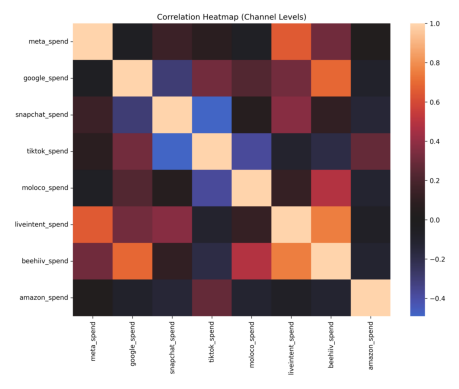

In [5]:
display_image("correlation_heatmap.png")

**Figure 1: Pairwise Pearson Correlation Heatmap of Marketing Channels.** *This heatmap visualizes the contemporaneous linear relationships between channel spends. High coefficients (e.g., Beehiiv/LiveIntent at 0.85) identify primary candidates for interaction modeling.*

The channel-level correlation heatmap shows strong positive relationships between several marketing channels, particularly LiveIntent and Beehiiv (≈0.85) and Google and Beehiiv (≈0.75), suggesting these channels tend to increase or decrease together. Meta and LiveIntent also exhibit a relatively strong correlation (around 0.65–0.70), indicating coordinated movement in spend. In contrast, some pairs show weak or negative relationships, such as Snapchat and TikTok (≈−0.45) and TikTok and Moloco (≈−0.30), suggesting these channels may operate more independently or shift budgets in opposite directions. Overall, the heatmap highlights clusters of channels—especially Beehiiv, LiveIntent, and Google—that tend to move together in the dataset.

## Investigating Lagged Correlation

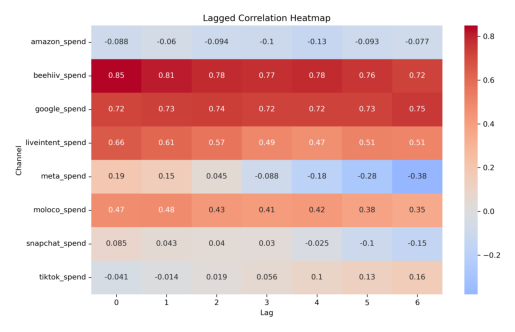

In [6]:
display_image("lagged_heatmap.png")

**Figure 2: Time-Lagged Target Correlation Heatmap.** *This visualization displays the relationship between channel spend at $t-n$ and the target variable at $t$. The data reveals a persistent relationship for Beehiiv and Google across 6 lags, contrasted by a notable negative decay in Meta’s performance over time.*

The lagged correlation heatmap shows that Beehiiv spend has the strongest correlations with the target across time, with values decreasing gradually from 0.85 at lag 0 to about 0.72 by lag 6, indicating a persistent relationship over time. Google spend also maintains consistently strong correlations, ranging from roughly 0.72–0.75 across all lags, while LiveIntent shows moderate correlations that decline from 0.66 at lag 0 to around 0.47–0.51 by later lags. In contrast, Meta’s correlation becomes increasingly negative over time (from about 0.19 at lag 0 to −0.38 at lag 6), and channels like Snapchat and TikTok show weak correlations overall (generally between −0.15 and 0.16).

Channels such as Meta, Snapchat, and TikTok show weak or declining correlations, which suggests their current spending patterns may not be strongly aligned with the target outcome being measured. For Meta in particular, the increasingly negative correlations could indicate issues such as targeting inefficiencies, measurement misalignment, or budget being deployed in response to demand rather than generating it. 

## Modeling and Quantifying Interactions

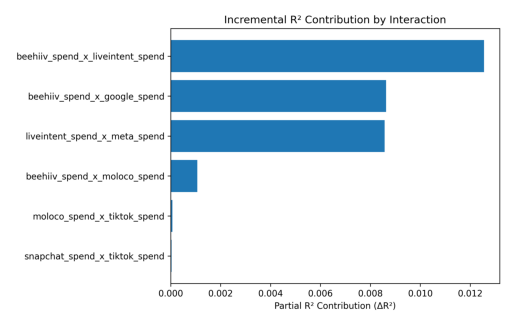

In [ ]:
display_image("partial_r2_interactions.png")

**Figure 3: Incremental Explanatory Power ($\Delta R^2$) of Interaction Terms.** *This chart quantifies the Partial $R^2$ contributed by adding specific pairwise interaction terms to the base linear model. The Beehiiv × LiveIntent interaction provides the most significant gain ($\Delta R^2 \approx 0.0125$), marking it as a primary driver of synergy.*

The interaction model shows that the strongest cross-channel synergy occurs between Beehiiv and LiveIntent, which adds about ΔR² ≈ 0.0125 of additional explanatory power to the model. Other notable interactions include Beehiiv × Google (ΔR² ≈ 0.0088) and LiveIntent × Meta (ΔR² ≈ 0.0087), both contributing meaningful but smaller improvements in model fit. In contrast, interactions such as Beehiiv × Moloco (~0.001) and those involving TikTok or Snapchat (≈0) add very little predictive value. Overall, only a few channel combinations meaningfully improve the model, with the strongest gains concentrated around interactions involving Beehiiv.

## Granger Causality Testing

In [ ]:
granger_casuality_summary = pd.read_csv("../interaction_strength_figs/granger_summary_with_fdr.csv")
granger_casuality_summary

,target,driver,best_lag,min_pvalue,fdr_qvalue,sig_p05,sig_fdr_05
0,amazon_spend,meta_spend,3,8.202508e-09,4.593404e-07,True,True
1,google_spend,liveintent_spend,3,5.795737e-04,1.622806e-02,True,True
2,beehiiv_spend,moloco_spend,2,5.869067e-03,1.095559e-01,True,False
3,meta_spend,amazon_spend,1,1.301752e-02,1.578698e-01,True,False
4,snapchat_spend,moloco_spend,1,1.409552e-02,1.578698e-01,True,False
5,liveintent_spend,beehiiv_spend,3,2.792908e-02,2.428559e-01,True,False
6,amazon_spend,tiktok_spend,2,3.177716e-02,2.428559e-01,True,False
7,tiktok_spend,amazon_spend,3,3.899923e-02,2.428559e-01,True,False
8,moloco_spend,liveintent_spend,3,3.903041e-02,2.428559e-01,True,False
9,google_spend,beehiiv_spend,3,5.976300e-02,3.322624e-01,False,False


**Table 1: Granger Causality Summary with Benjamini–Hochberg (FDR) Correction.** *This summary identifies predictive lead-lag relationships between channels. After applying FDR correction to mitigate false positives, only Meta → Amazon (Lag 3) and LiveIntent → Google (Lag 3) remain statistically robust ($q < 0.05$).*

After correcting for multiple hypothesis testing using FDR, the results suggest that there are only two interactions remain siginficant: Meta spend predicting Amazon spend at lag 3, and LiveIntent spend predicting Google spend at lag 3. Several additional channel pairs were significant at the nominal 5% level, but these did not survive FDR correction and should be treated as exploratory rather than confirmatory. Overall, the results suggest a sparse lead-lag structure in channel spend, with only a small number of robust cross-channel predictive relationships.

Across the analyses, a consistent pattern emerges in which Beehiiv, LiveIntent, and Google appear to form the strongest cluster of related channels. The correlation heatmaps show high contemporaneous relationships—such as LiveIntent–Beehiiv (≈0.85) and Google–Beehiiv (≈0.75)—and these relationships remain strong across lags, with Beehiiv maintaining correlations from about 0.85 at lag 0 to ~0.72 by lag 6 and Google staying around 0.72–0.75 across all lags. The interaction model reinforces this pattern, with the largest incremental contribution coming from Beehiiv × LiveIntent (ΔR² ≈ 0.0125) and additional gains from Beehiiv × Google (ΔR² ≈ 0.0088) and LiveIntent × Meta (ΔR² ≈ 0.0087). However, the Granger causality results indicate that only two predictive relationships remain statistically robust after FDR correction—Meta → Amazon (lag 3) and LiveIntent → Google (lag 3)—suggesting that while several channels move together or interact in the model, only a small number exhibit strong lead–lag predictive effects.

### Interaction Modeling Results


In [ ]:
import pandas as pd
from IPython.display import Image

interaction_results = pd.read_csv("../interaction_strength_figs/interaction_effects.csv")
partial_r2_results = pd.read_csv("../interaction_strength_figs/interaction_partial_r2.csv")

In [ ]:
interaction_results

,interaction,coef,lower_95,upper_95,abs_coef
0,beehiiv_spend_x_google_spend,-736.994310,-1551.279013,77.290394,736.994310
1,beehiiv_spend_x_liveintent_spend,612.438783,51.385807,1173.491759,612.438783
2,liveintent_spend_x_meta_spend,-250.213180,-527.596817,27.170458,250.213180
3,beehiiv_spend_x_moloco_spend,-151.329039,-627.042228,324.384149,151.329039
4,moloco_spend_x_tiktok_spend,-57.337634,-761.515796,646.840527,57.337634
5,snapchat_spend_x_tiktok_spend,28.079755,-474.552185,530.711695,28.079755


In [ ]:
partial_r2_results

,interaction,partial_r2
0,beehiiv_spend_x_liveintent_spend,0.012556
1,beehiiv_spend_x_google_spend,0.008632
2,liveintent_spend_x_meta_spend,0.008574
3,beehiiv_spend_x_moloco_spend,0.001066
4,moloco_spend_x_tiktok_spend,0.000070
5,snapchat_spend_x_tiktok_spend,0.000033


In [ ]:
ci_results = pd.read_csv("../interaction_strength_figs/interaction_ci_clean.csv")
print("95% Confidence Intervals for Interaction Terms:")
ci_results

95% Confidence Intervals for Interaction Terms:


,Unnamed: 0,coefficient,lower_95,upper_95,is_significant
0,beehiiv_spend_x_liveintent_spend,612.438783,51.385807,1173.491759,True
1,beehiiv_spend_x_google_spend,-736.994310,-1551.279013,77.290394,False
2,liveintent_spend_x_meta_spend,-250.213180,-527.596817,27.170458,False
3,snapchat_spend_x_tiktok_spend,28.079755,-474.552185,530.711695,False
4,beehiiv_spend_x_moloco_spend,-151.329039,-627.042228,324.384149,False
5,moloco_spend_x_tiktok_spend,-57.337634,-761.515796,646.840527,False


**Table 2: 95% Confidence Intervals for Interaction Coefficients.** *This table validates the statistical significance of modeled interaction effects. Only the Beehiiv × LiveIntent coefficient interval excludes zero, confirming a reliable and statistically significant synergistic relationship for the current dataset.*

### Interpretation of Results

After adding the interaction terms, the model achieved an R² of 0.845, meaning it explains about 84.5% of the variation in subscriptions. This is slightly better than the model without interactions, which suggests that some cross-channel effects may exist.

Looking at the interaction coefficients, the largest effects appear for Beehiiv × Google, Beehiiv × LiveIntent, and LiveIntent × Meta. However, when we check the 95% confidence intervals, only Beehiiv × LiveIntent does not include zero. This suggests there is clear positive synergy between these two channels, meaning they seem to work better together than individually.

The other interactions have larger uncertainty because their confidence intervals cross zero, so they should be interpreted as possible signals rather than strong conclusions.

We also calculated Partial R² to see how much each interaction improves the model. Beehiiv × LiveIntent contributes the most additional explanatory power, followed by Beehiiv × Google and LiveIntent × Meta, while the other interactions add very little to the model.

# Discussion

The primary objective of this phase was to move beyond the standard MMM assumption of channel independence to identify where marketing efforts either amplify (synergy) or overlap (cannibalization). Our analysis successfully shifted the project from a purely correlative approach to a more rigorous statistical validation of these interactions.

### Interpretation of Interconnectivity

A consistent narrative across our heatmaps and regression models is the existence of a "High-Engagement Cluster" consisting of Beehiiv, LiveIntent, and Google. These channels don’t just move together; they appear to fundamentally reinforce one another. The interaction between Beehiiv and LiveIntent was the only one to remain statistically significant at the 95% confidence level ($p < 0.05$), providing a concrete example of synergy. This suggests that the audience overlap or the sequence of exposure between these two platforms creates a "1 + 1 = 3" effect on subscriptions.

### Challenges with Statistical Significance

One significant hurdle was the "noise" inherent in high-dimensional marketing data. While several channel pairs (like Beehiiv × Google) showed relatively high Partial $R^2$ values, their 95% confidence intervals still crossed zero. This highlight a common challenge in MMM: distinguishing between a genuine strategic interaction and a coincidental correlation in spend. Furthermore, the Granger Causality results proved to be quite sparse. After applying the Benjamini-Hochberg (FDR) correction, most of the initially "significant" lead-lag relationships vanished. This indicates that while many channels are correlated in the present (contemporaneously), very few have a robust predictive power over the future performance of other channels.

### Strategic Implications

The findings suggest that the client’s current marketing mix is highly concentrated in its effects. The fact that Meta showed increasingly negative correlations with the target over time (from 0.19 at lag 0 to -0.38 at lag 6) is a critical point for discussion. This could indicate cannibalization or a "wear-out" effect, where increased spend on Meta over time is not being matched by a corresponding increase in subscriptions, potentially due to audience saturation or competition with other digital channels like TikTok.

# Future Work

As we transition into the Spring quarter, our team will shift from detection to integration. We have identified the "what" (which channels interact); next, we must solve the "how" (how to optimize for them).

The primary goal for Spring quarter is to explicitly incorporate interaction terms into the Meridian model and evaluate how they affect channel-level ROI estimation. Rather than treating channels as independent predictors, we will include selected interaction terms-such as Beehiiv × LiveIntent and Beehiiv × Google-based on their statistical significance and contribution to model fit. This will allow us to assess whether accounting for synergy or cannibalization leads to materially different budget allocation recommendations.

A key extension will be the comparison of model performance with and without interaction terms. This includes evaluating changes in $R^2$, prediction error, and stability of coefficient estimates, as well as analyzing how interaction modeling impacts inferred channel effectiveness. In particular, we aim to quantify whether ignoring interactions leads to overestimation or underestimation of certain channels’ ROI.

In addition, we plan to incorporate insights from the Granger causality and lagged analyses into the modeling framework. This includes experimenting with lagged interaction terms to capture delayed synergy effects and using identified lead–lag relationships to better structure the temporal dynamics of the model.

Another important deliverable will be the development of a network-based visualization of channel relationships, where nodes represent channels and edges represent the strength and type (synergy or cannibalization) of interactions. This will provide an intuitive and interpretable way for stakeholders to understand complex cross-channel dynamics and identify key drivers within the marketing ecosystem.

# References

Charan, A. (n.d.). Interaction Effects in Marketing Mix Modelling. National University of Singapore.

Google Developers. (2024). About Meridian: An open-source Marketing Mix Modeling (MMM) framework. https://developers.google.com/meridian

Kollmann, T., Kuckertz, A., & Ellis, S. (2012). Cannibalization or Synergy? Consumers' Channel Selection in Online-Offline Multichannel Systems. Journal of Retailing and Consumer Services.